# FORCE 2020 Exploratory Data Analysis

This notebook examines lithofacies composition, interpretation confidence, petrophysical log distributions, data completeness, and relationships between well-log response and interpreted lithology across the FORCE 2020 dataset.
#### Objectives
- Assess lithofacies distribution and interpretation confidence
- Examine log distributions, completeness, and variation between lithofacies
- Evaluate cross-log relationships and representative well-log responses

#### Primary references:

- Bormann, P., Aursand, P., Dilib, F., Dischington, P., and Manral, S. (2020), FORCE Machine Learning Competition.
- Zenodo dataset record: `https://zenodo.org/records/4351156`
- FORCE competition repository: `https://github.com/bolgebrygg/Force-2020-Machine-Learning-competition`
- FORCE competition overview and lithology key: `https://thinkonward.com/app/c/challenges/force-well-logs/overview`
- CREWES Research Report, *Log Facies Classification Contest Pitfalls* (2020): `https://www.crewes.org/ForOurSponsors/ResearchReports/2020/CRR202018.pdf`


In [19]:
### imports
import os
from pathlib import Path

import lasio
import numpy as np
import pandas as pd

print(np.__version__)
print(pd.__version__)

### plotting
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.patches import Patch
from matplotlib.ticker import FuncFormatter

import plotly.io as pio
from IPython.display import HTML, display
from plotly.subplots import make_subplots
import plotly.graph_objects as go



import random
import sys

### PROJ projection and transformation libraries 
### https://www.lizardtech.com/post/getting-started-with-pyproj-in-python
import pyproj 
proj_path = os.path.join(sys.prefix, "share", "proj")
pyproj.datadir.set_data_dir(proj_path)
from pyproj import CRS, Transformer
import pygmt

try:
    import ipympl
except ImportError:
    %pip install ipympl

try:
    import kaleido
except ImportError:
    %pip install --upgrade "kaleido>=1"

from PIL import Image

import ipywidgets as widgets

### pandas displays floats to 2dp for ease of reading
pd.set_option('display.float_format', lambda x: '%.2f' % x)

import duckdb

1.26.4
2.3.3


In [20]:
### establish unit conversions

FT_PER_M = 3.28084

In [21]:
### make plots interactive
# %matplotlib widget

### make plots static 
%matplotlib inline

In [22]:
### set project paths 

cwd = Path.cwd()
project_dir = cwd.parent
data_root_dir = project_dir.parent / "data"

def list_contents(dir):
    print(f'\nELEMENTS IN /{os.path.basename(dir)}/:')
    print(f'{sorted(path.name for path in dir.iterdir())}')

list_contents(project_dir)
list_contents(data_root_dir)

data_dir = data_root_dir / 'force_2020_well_log_analysis' / 'Force_2020_all_wells'

LAS_FILES = sorted(data_dir.glob("*.las"))
print(f"LAS files found: {len(LAS_FILES)}")

list_contents(data_dir)


ELEMENTS IN /force_2020_well_log_analysis/:
['.DS_Store', '.git', '.gitignore', '.venv', '.vscode', 'README.md', 'images', 'notebooks', 'outputs', 'sql']

ELEMENTS IN /data/:
['.DS_Store', 'coreloggers', 'fmi_wrapper', 'force_2020_well_log_analysis', 'north_atlantic_seafloor_analysis']
LAS files found: 118

ELEMENTS IN /Force_2020_all_wells/:
['15_9-13.las', '15_9-14.las', '15_9-15.las', '15_9-17.las', '15_9-23.las', '16_1-2.las', '16_1-6 A.las', '16_10-1.las', '16_10-2.las', '16_10-3.las', '16_10-5.las', '16_11-1 ST3.las', '16_2-11 A.las', '16_2-16.las', '16_2-6.las', '16_2-7.las', '16_4-1.las', '16_5-3.las', '16_7-4.las', '16_7-5.las', '16_7-6.las', '16_8-1.las', '17_11-1.las', '17_4-1.las', '25_10-10.las', '25_10-9.las', '25_11-15.las', '25_11-19 S.las', '25_11-24.las', '25_11-5.las', '25_2-13 T4.las', '25_2-14.las', '25_2-7.las', '25_3-1.las', '25_4-5.las', '25_5-1.las', '25_5-3.las', '25_5-4.las', '25_6-1.las', '25_6-2.las', '25_6-3.las', '25_7-2.las', '25_8-5 S.las', '25_8-7.las

## 1. Build EDA sample table
Only the curves needed for this stage are collected into one sample-level dataframe. The first-pass petrophysical set is `GR`, `RHOB`, `NPHI`, `DTC`, `RDEP`, and `PEF`.

In [23]:
### force 2020 lithofacies definitions
### keys and further information may be found in https://github.com/bolgebrygg/Force-2020-Machine-Learning-competition/blob/master/lithology_competition/data/starter_notebook.ipynb

LITHOLOGY_CURVE = "FORCE_2020_LITHOFACIES_LITHOLOGY"
CONFIDENCE_CURVE = "FORCE_2020_LITHOFACIES_CONFIDENCE"

LITHOLOGY_NAMES = {
    30000: "Sandstone",
    65030: "Sandstone/Shale",
    65000: "Shale",
    80000: "Marl",
    74000: "Dolomite",
    70000: "Limestone",
    70032: "Chalk",
    88000: "Halite",
    86000: "Anhydrite",
    99000: "Tuff",
    90000: "Coal",
    93000: "Basement",
}

CONFIDENCE_NAMES = {
    1: "High",
    2: "Medium",
    3: "Low",
}

KEY_LOGS = [
    "GR",
    "RHOB",
    "NPHI",
    "DTC",
    "RDEP",
    "PEF",
]

EDA_CURVES = KEY_LOGS + [
    LITHOLOGY_CURVE,
    CONFIDENCE_CURVE,
]

In [24]:
### helper functions
def get_well_name(las, path):
    try:
        value = las.well["WELL"].value
    except (KeyError, AttributeError):
        value = path.stem

    if pd.isna(value) or str(value).strip() == "":
        value = path.stem

    return str(value)


def get_curve_units(las, curve_names):
    units = {}

    for curve in las.curves:
        if curve.mnemonic in curve_names:
            unit = str(curve.unit).strip()
            if unit:
                units.setdefault(curve.mnemonic, set()).add(unit)

    return units


### read selected curves from all wells
sample_frames = []
unit_records = {}
read_errors = []

for path in LAS_FILES:
    try:
        las = lasio.read(path)
        df = las.df()
        well_name = get_well_name(las, path)

        depth_m = np.asarray(
            pd.to_numeric(df.index, errors="coerce"),
            dtype=float,
        )

        well_data = pd.DataFrame(
            index=np.arange(len(df)),
        )

        well_data["well"] = well_name
        well_data["file"] = path.name
        well_data["depth_m"] = depth_m
        well_data["depth_ft"] = depth_m * FT_PER_M

        for curve in EDA_CURVES:
            if curve in df.columns:
                well_data[curve] = pd.to_numeric(
                    df[curve].to_numpy(),
                    errors="coerce",
                )
            else:
                well_data[curve] = np.nan

        sample_frames.append(well_data)

        for curve, units in get_curve_units(las, KEY_LOGS).items():
            unit_records.setdefault(curve, set()).update(units)

    except Exception as error:
        read_errors.append(
            {
                "file": path.name,
                "error": str(error),
            }
        )

samples = pd.concat(sample_frames, ignore_index=True)

samples["well"] = samples["well"].astype("category")
samples["file"] = samples["file"].astype("category")

samples["lithology_code"] = (
    pd.to_numeric(samples[LITHOLOGY_CURVE], errors="coerce")
    .round()
    .astype("Int64")
)

samples["confidence_code"] = (
    pd.to_numeric(samples[CONFIDENCE_CURVE], errors="coerce")
    .round()
    .astype("Int64")
)

facies_order = list(LITHOLOGY_NAMES.values())

### define lithofacies color key for notebook
### tab20 is a discrete colormap with 20 unique values, n number of values are selected, matching number of facies labels
tab20 = plt.get_cmap("tab20")
### list comprehension builds ordered list of color tuples matching n number of bars
FACIES_COLORS = {facies: tab20(i) for i, facies in enumerate(facies_order)}

samples["lithofacies"] = pd.Categorical(
    samples["lithology_code"].map(LITHOLOGY_NAMES),
    categories=facies_order,
    ordered=True,
)

samples["confidence"] = pd.Categorical(
    samples["confidence_code"].map(CONFIDENCE_NAMES),
    categories=list(CONFIDENCE_NAMES.values()),
    ordered=True,
)

curve_units = pd.Series(
    {
        curve: ", ".join(sorted(units))
        for curve, units in unit_records.items()
    },
    name="unit",
).reindex(KEY_LOGS)

unknown_lithology_codes = sorted(
    set(samples["lithology_code"].dropna().astype(int).unique())
    - set(LITHOLOGY_NAMES)
)

print(f"Samples loaded: {len(samples):,}")
print(f"Wells loaded: {samples['well'].nunique():,}")
print(f"Labeled samples: {samples['lithofacies'].notna().sum():,}")
print(f"Labeled wells: {samples.loc[samples['lithofacies'].notna(), 'well'].nunique():,}")
print(f"Read errors: {len(read_errors):,}")
print(f"Unknown lithology codes: {unknown_lithology_codes or 'none'}")

display(curve_units.to_frame())

if read_errors:
    display(pd.DataFrame(read_errors))

Samples loaded: 2,337,639
Wells loaded: 118
Labeled samples: 1,431,383
Labeled wells: 118
Read errors: 0
Unknown lithology codes: none


,unit
GR,gAPI
RHOB,g/cm3
NPHI,m3/m3
DTC,us/ft
RDEP,ohm.m
PEF,b/e


In [25]:
labeled_samples = samples.loc[
    samples["lithofacies"].notna()
].copy()

### how many, of all the depth rows hold labels
n_total = len(samples)
n_labeled = samples["lithofacies"].notna().sum()
n_unlabeled = n_total - n_labeled

label_coverage = pd.DataFrame(
    {
        "samples": [n_labeled, n_unlabeled],
        "percentage": [
            100 * n_labeled / n_total,
            100 * n_unlabeled / n_total,
        ],
    },
    index=["Labeled", "Unlabeled"],
)

display(label_coverage)

,samples,percentage
Labeled,1431383,61.23
Unlabeled,906256,38.77


In [26]:
### lithology,keys and further information may be found in https://github.com/bolgebrygg/Force-2020-Machine-Learning-competition/blob/master/lithology_competition/data/starter_notebook.ipynb


LITHOLOGY_column = "FORCE_2020_LITHOFACIES_LITHOLOGY"

lithology_records = []

for path in LAS_FILES:
    las = lasio.read(path)
    df = las.df()

    if LITHOLOGY_column not in df.columns:
        continue

    lithology = (
        pd.to_numeric(
            df[LITHOLOGY_column],
            errors="coerce",
        )
        .dropna()
        .astype(int)
    )

    lithology_records.extend(lithology.tolist())

lithology_counts = (
    pd.Series(lithology_records, name="code")
    .value_counts()
    .rename_axis("code")
    .reset_index(name="samples")
)

lithology_counts["lithofacies"] = (
    lithology_counts["code"]
    .map(LITHOLOGY_NAMES)
    .fillna("Unknown")
)

lithology_counts["percentage"] = (
    lithology_counts["samples"]
    / lithology_counts["samples"].sum()
    * 100
)




### facies summary
facies_summary = (
    labeled_samples["lithofacies"]
    .value_counts(sort=False)
    .rename("samples")
    .to_frame()
)

facies_summary["%_labeled"] = (
    100 * facies_summary["samples"] / n_labeled
)

facies_summary["%_all_rows"] = (
    100 * facies_summary["samples"] / n_total
)

facies_summary = facies_summary.sort_values(
    "samples",
    ascending=False,
)

print(f'number of facies labels: {len(facies_summary)}\n')

display(facies_summary)



number of facies labels: 12



,samples,%_labeled,%_all_rows
lithofacies,,,
Shale,877043,61.27,37.52
Sandstone,207704,14.51,8.89
Sandstone/Shale,180820,12.63,7.74
Limestone,69498,4.86,2.97
Marl,41038,2.87,1.76
Tuff,17431,1.22,0.75
Halite,14712,1.03,0.63
Chalk,14043,0.98,0.60
Coal,4754,0.33,0.20


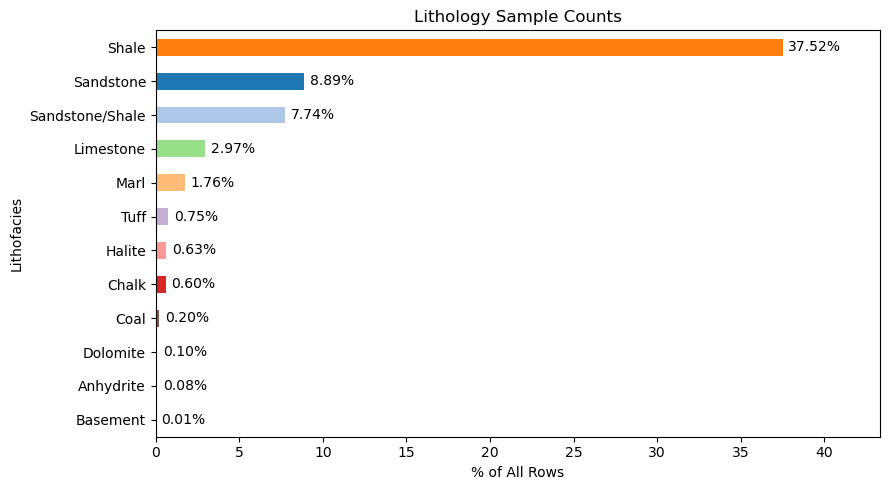

In [57]:
### plot lithology presence
colors = [FACIES_COLORS[facies] for facies in facies_summary.index]

ax = facies_summary["%_all_rows"].plot(
    kind="barh", 
    legend=False,
    color=colors,
    figsize=(9, 5),
)
ax.invert_yaxis()
### annotate percentage value above each bar
ax.bar_label(ax.containers[0], fmt="%.2f%%", padding=4)
### padding so percentage overlaps not
ax.set_xlim(right=ax.get_xlim()[1] * 1.1)

plt.ylabel("Lithofacies")
plt.xlabel("% of All Rows")
plt.title("Lithology Sample Counts")
plt.tight_layout()
plt.show()

#### Observations:

Only about 61% of all rows are labeled, <39% unlabeled.

Of all rows (labeled and unlabled), over a third are shales (<38%), ~9% are sandstones and <8% are mixed sandstone/shale. 

Limestones (~3%) and marls (<2%) with the reamining lithologies being uncommon.

So most of the labels fall inbetween three quite similar siliciclastic classes. So this may have a more mixed than defined signature from the wireline logs.

## 2. Lithofacies composition by well

The following matrix shows the percentage of labeled samples assigned to each facies within each well. 

In [28]:
def plot_matrix(
    matrix,
    discrete=False,
    title="Matrix Heatmap",
    xlabel="Columns",
    ylabel="Rows",
    cbar_label="Value",
    cmap="viridis",
    aspect="auto",
):
    plot_matrix = matrix.copy()

    # convert binary availability (0 to 1) to percentages
    values = plot_matrix.to_numpy()
    finite_values = values[np.isfinite(values)]

    if len(finite_values) and np.all(np.isin(finite_values, [0, 1])):
        plot_matrix = plot_matrix * 100
        values = plot_matrix.to_numpy()
        finite_values = values[np.isfinite(values)]

    # calculate dynamic figure height for long row labels
    fig_height = max(10, len(matrix.index) * 0.16)
    fig, ax = plt.subplots(figsize=(11, fig_height))

    # configure colormap and normalization for discrete mode
    if discrete:
        vmin = float(np.nanmin(finite_values)) if len(finite_values) else 0.0
        vmax = float(np.nanmax(finite_values)) if len(finite_values) else 100.0

        if vmin == vmax:
            vmin -= 0.5
            vmax += 0.5

        levels = np.linspace(vmin, vmax, 15)
        base_cmap = plt.get_cmap(cmap)
        cmap_obj = mcolors.ListedColormap(base_cmap(np.linspace(0, 1, 14)))
        norm = mcolors.BoundaryNorm(boundaries=levels, ncolors=14)
        ticks = levels
    else:
        cmap_obj = cmap
        norm = None
        ticks = np.arange(0, 101, 10)

    image = ax.imshow(
        plot_matrix,
        aspect=aspect,
        interpolation="nearest",
        cmap=cmap_obj,
        norm=norm,
        vmin=None if discrete else 0,
        vmax=None if discrete else 100,
    )

    colorbar = fig.colorbar(
        image,
        ax=ax,
        ticks=ticks,
        pad=0.02,
    )
    colorbar.set_label(cbar_label)

    # axis labels setup
    ax.set_xticks(range(len(matrix.columns)))
    ax.set_xticklabels(matrix.columns, rotation=45, ha="right")

    ax.set_yticks(range(len(matrix.index)))
    ax.set_yticklabels(matrix.index.astype(str))

    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.set_title(title)

    # minor grid lines between cells
    ax.set_xticks([x - 0.5 for x in range(1, len(matrix.columns))], minor=True)
    ax.set_yticks([y - 0.5 for y in range(1, len(matrix.index))], minor=True)
    ax.grid(which="minor", color="black", linestyle="-", linewidth=0.5)
    ax.tick_params(which="minor", size=0)

    plt.tight_layout()
    plt.show()

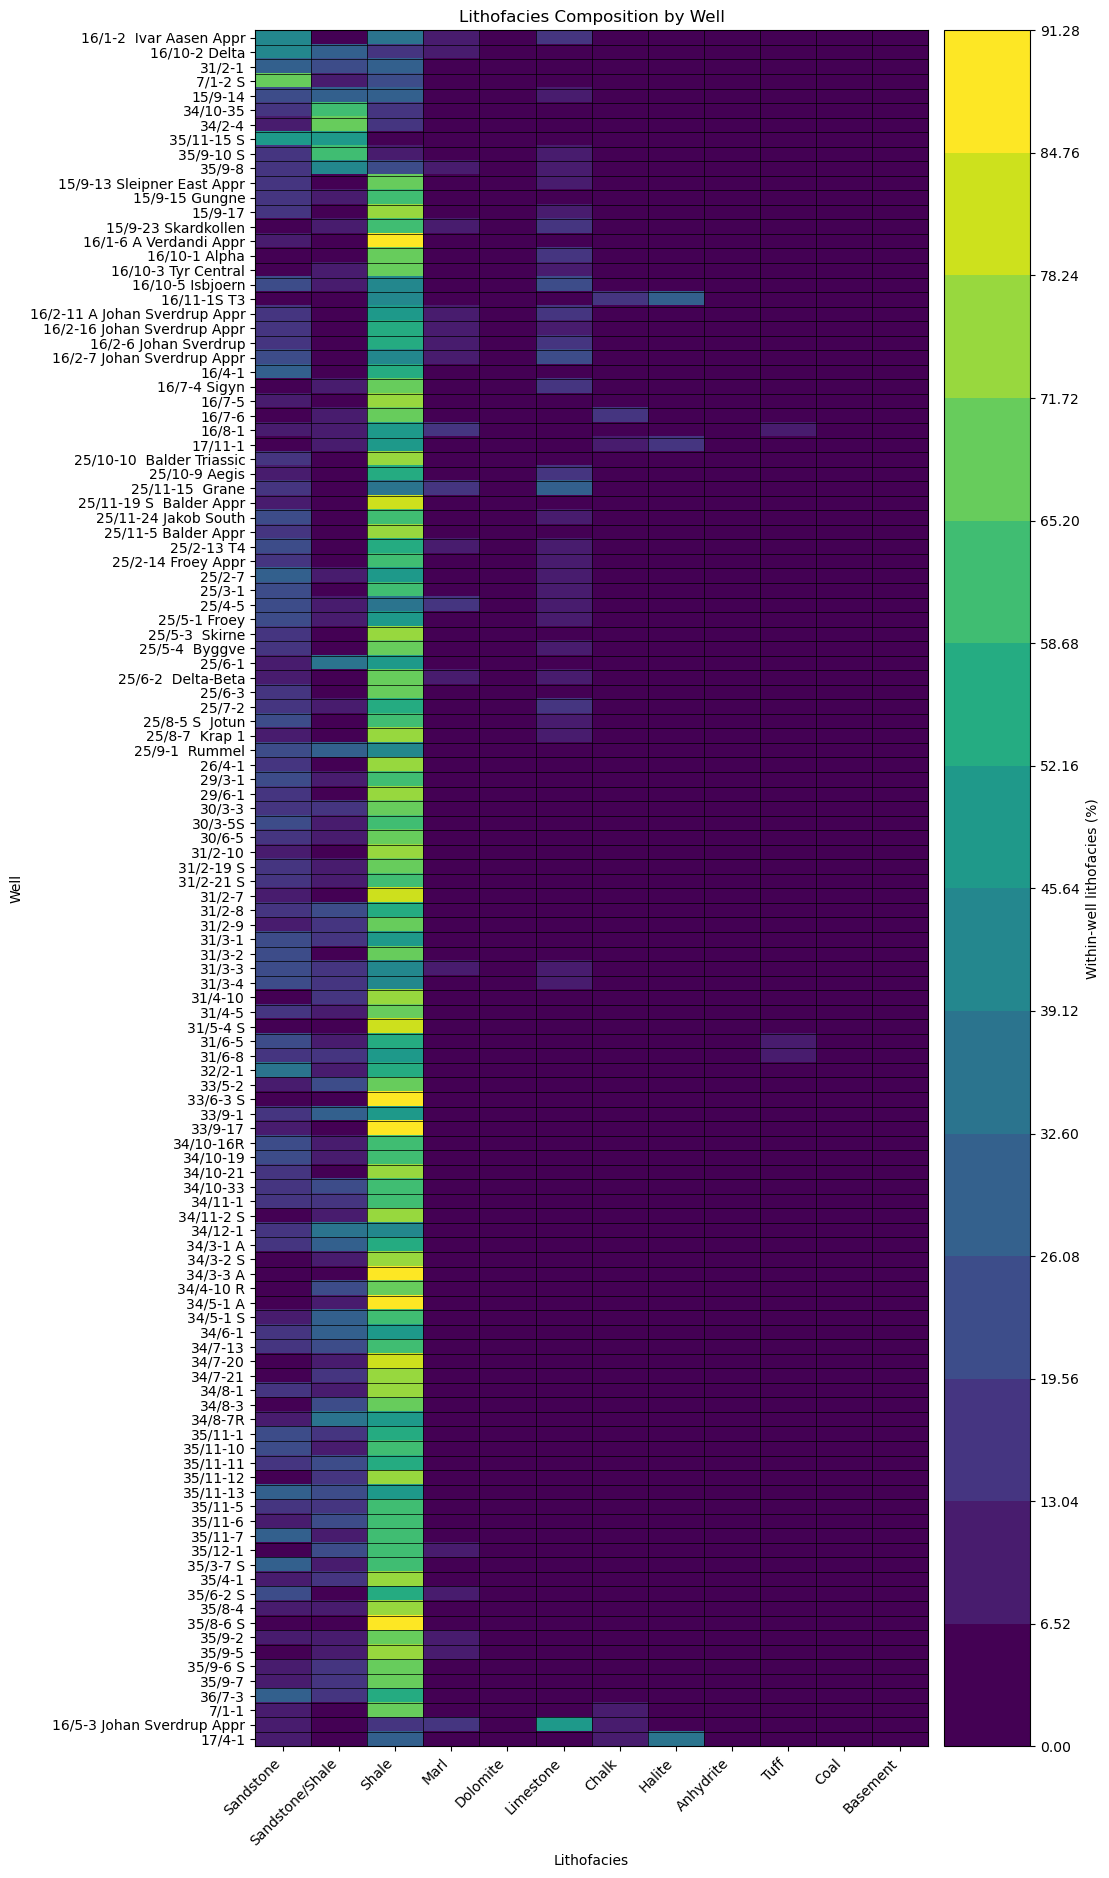

In [29]:
# calculate lithofacies percentage within each well
facies_by_well = pd.crosstab(
    labeled_samples["well"],
    labeled_samples["lithofacies"],
    normalize="index",
) * 100

facies_by_well = facies_by_well.reindex(
    columns=facies_order,
    fill_value=0,
)

well_dominant_facies = facies_by_well.idxmax(axis=1)
dominant_rank = well_dominant_facies.map(
    {facies: rank for rank, facies in enumerate(facies_order)}
)

well_order = (
    pd.DataFrame(
        {
            "well_label": facies_by_well.index.astype(str),
            "dominant_rank": dominant_rank.to_numpy(),
        },
        index=facies_by_well.index,
    )
    .sort_values(["dominant_rank", "well_label"])
    .index
)

facies_by_well = facies_by_well.loc[well_order]

# call generalized plot function
plot_matrix(
    matrix=facies_by_well,
    discrete=True,
    title="Lithofacies Composition by Well",
    xlabel="Lithofacies",
    ylabel="Well",
    cbar_label="Within-well lithofacies (%)",
    cmap="viridis",
)

##### Observations:

Shale is again the predominant facies across most wells, while the proportions of the secondary facies vary between wells.

## 3. Interpretation confidence

FORCE provides an interpretation-confidence code with the labels: `1 = high`, `2 = medium`, and `3 = low`. Confidence is first examined globally, then within each lithofacies.

In [30]:
### summarize interpretation confidence
confidence_samples = labeled_samples.loc[
    labeled_samples["confidence"].notna()
].copy()

confidence_counts = (
    confidence_samples["confidence"]
    .value_counts(sort=False)
    .reindex(list(CONFIDENCE_NAMES.values()), fill_value=0)
    .rename("samples")
    .to_frame()
)

confidence_counts["percentage"] = (
    confidence_counts["samples"]
    / confidence_counts["samples"].sum()
    * 100
)

confidence_counts

,samples,percentage
confidence,,
High,1254007,87.62
Medium,137034,9.58
Low,40110,2.80


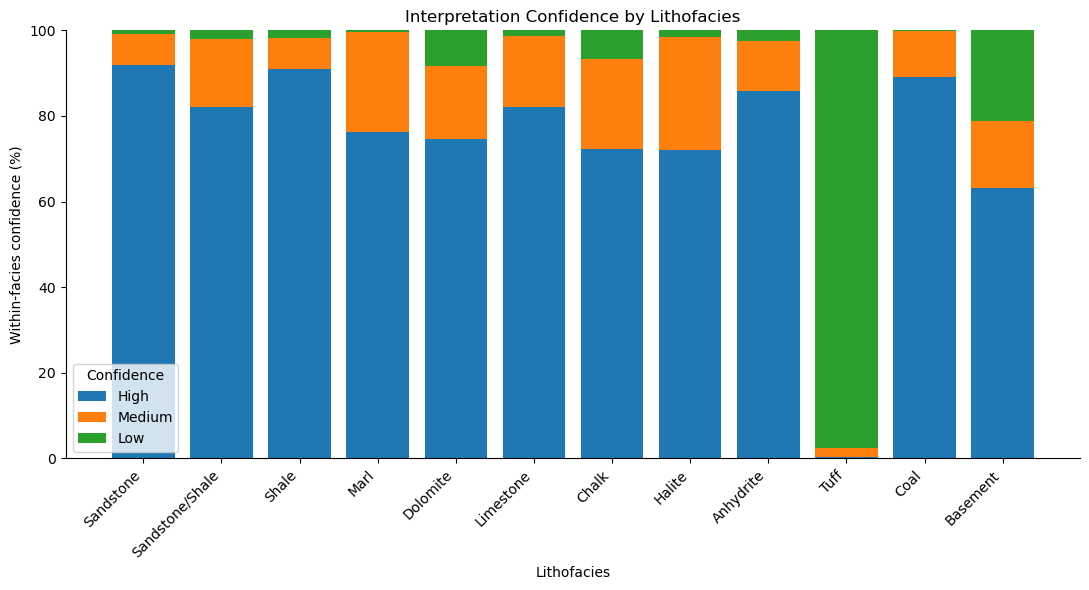

In [31]:
### plot confidence composition within each lithofacies
confidence_by_facies = pd.crosstab(
    confidence_samples["lithofacies"],
    confidence_samples["confidence"],
    normalize="index",
) * 100

confidence_by_facies = confidence_by_facies.reindex(
    index=facies_order,
    columns=list(CONFIDENCE_NAMES.values()),
    fill_value=0,
)

fig, ax = plt.subplots(figsize=(11, 6))
bottom = np.zeros(len(confidence_by_facies))

for confidence in confidence_by_facies.columns:
    values = confidence_by_facies[confidence].to_numpy()
    ax.bar(
        confidence_by_facies.index,
        values,
        bottom=bottom,
        label=confidence,
    )
    bottom += values

ax.set_ylabel("Within-facies confidence (%)")
ax.set_xlabel("Lithofacies")
ax.set_title("Interpretation Confidence by Lithofacies")
ax.set_ylim(0, 100)
ax.tick_params(axis="x", rotation=45)
plt.setp(ax.get_xticklabels(), ha="right")
ax.legend(title="Confidence")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

##### Observations

Interpretation confidence is strongly weighted toward High, about 88% of labeled samples.

## 4. Selected-log distributions

The global distributions provide a first check of scale, skew, tails, and acquisition differences. Histograms use the central 98% of each curve for display only.



Deep resistivity is plotted on a logarithmic x-axis because resistivity commonly spans several orders of magnitude.

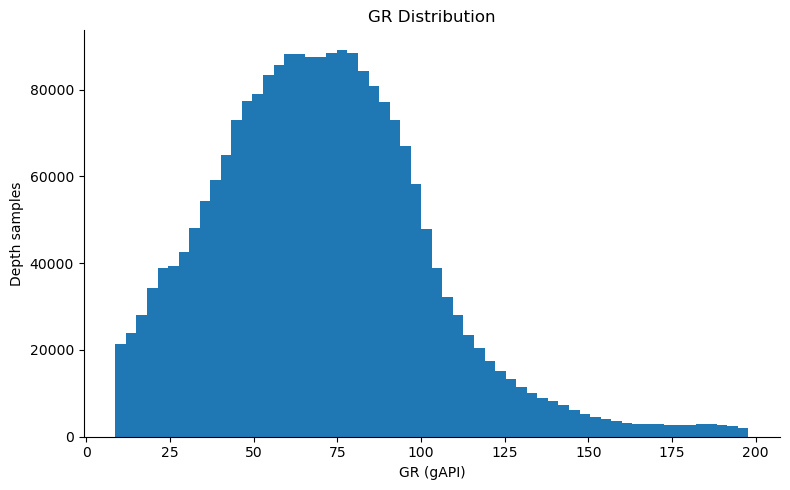

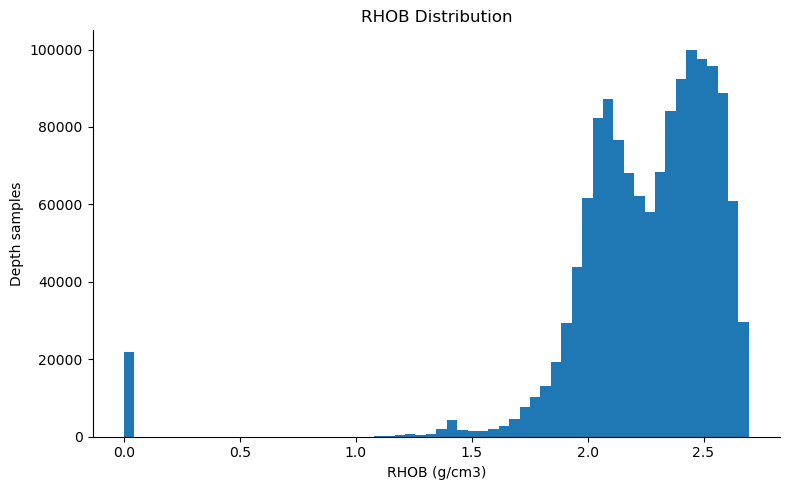

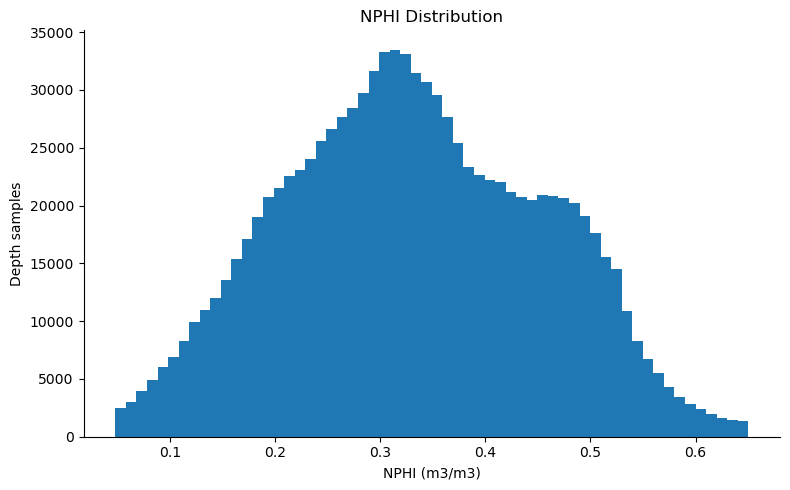

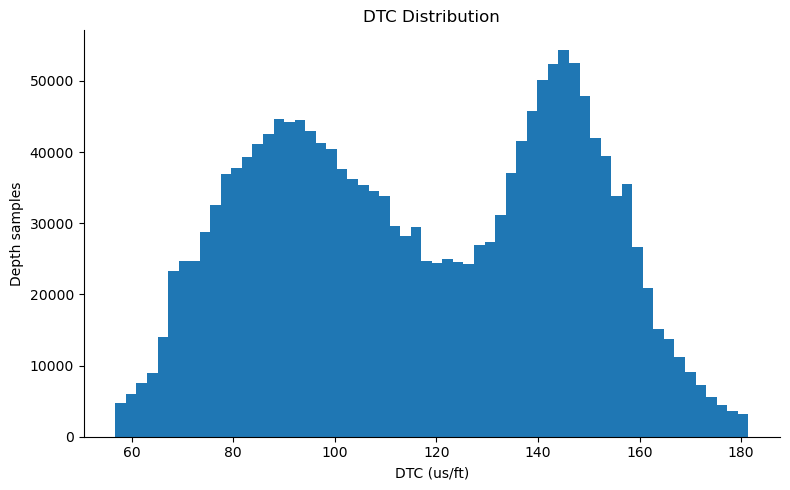

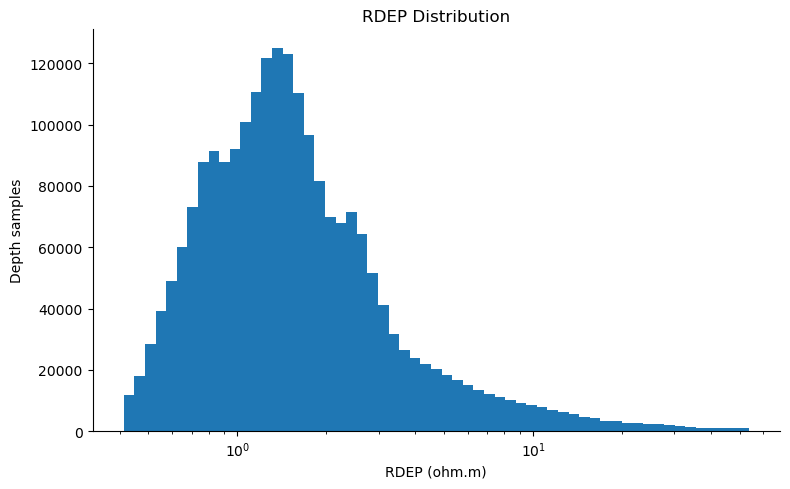

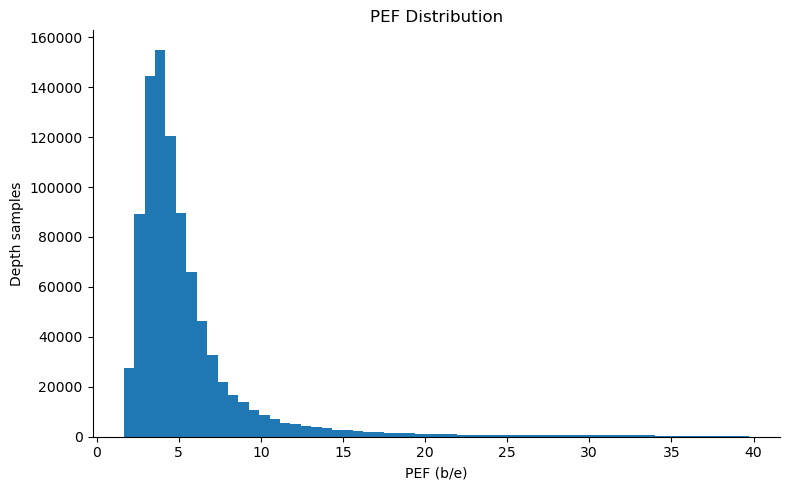

In [32]:
### define plotting labels and percentile limits
def curve_label(curve):
    unit = curve_units.get(curve)

    if pd.isna(unit) or str(unit).strip() == "":
        return curve

    return f"{curve} ({unit})"


def central_plot_range(series, lower=0.01, upper=0.99):
    valid = pd.to_numeric(series, errors="coerce").dropna()

    if valid.empty:
        return np.nan, np.nan

    return tuple(valid.quantile([lower, upper]).to_numpy())


plot_limits = {}

for curve in KEY_LOGS:
    values = samples[curve]

    if curve == "RDEP":
        values = values.loc[values > 0]

    plot_limits[curve] = central_plot_range(values)

pd.DataFrame(
    plot_limits,
    index=["p01", "p99"],
).T

### plot one distribution for each principal log
def plot_log_distribution(data, curve):
    values = pd.to_numeric(data[curve], errors="coerce").dropna()

    if curve == "RDEP":
        values = values.loc[values > 0]

    if values.empty:
        print(f"No valid values for {curve}")
        return

    lower, upper = central_plot_range(values)
    display_values = values.loc[
        values.between(lower, upper)
    ]

    fig, ax = plt.subplots(figsize=(8, 5))

    if curve == "RDEP":
        bins = np.logspace(
            np.log10(lower),
            np.log10(upper),
            60,
        )
        ax.hist(display_values, bins=bins)
        ax.set_xscale("log")
    else:
        ax.hist(display_values, bins=60)

    ax.set_xlabel(curve_label(curve))
    ax.set_ylabel("Depth samples")
    ax.set_title(f"{curve} Distribution")
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    plt.tight_layout()
    plt.show()


for curve in KEY_LOGS:
    plot_log_distribution(samples, curve)

## 5. Log distributions by lithofacies

This comparison asks whether the principal logs occupy distinguishable ranges for the interpreted lithofacies.

To keep plotting responsive while preserving rare classes, each facies contributes at most 20,000 randomly selected valid samples per plot. This sampling affects the visualization only. 

In [33]:
### make a balanced plotting sample across lithofacies
def stratified_plot_sample(data, group_column, max_per_group=20000):
    frames = []

    for _, group in data.groupby(group_column, observed=True):
        if len(group) > max_per_group:
            group = group.sample(
                n=max_per_group,
                random_state=42,
            )

        frames.append(group)

    return pd.concat(frames, ignore_index=True)


facies_plot_sample = stratified_plot_sample(
    labeled_samples,
    "lithofacies",
)

print(f"Samples retained for facies plots: {len(facies_plot_sample):,}")

Samples retained for facies plots: 155,280


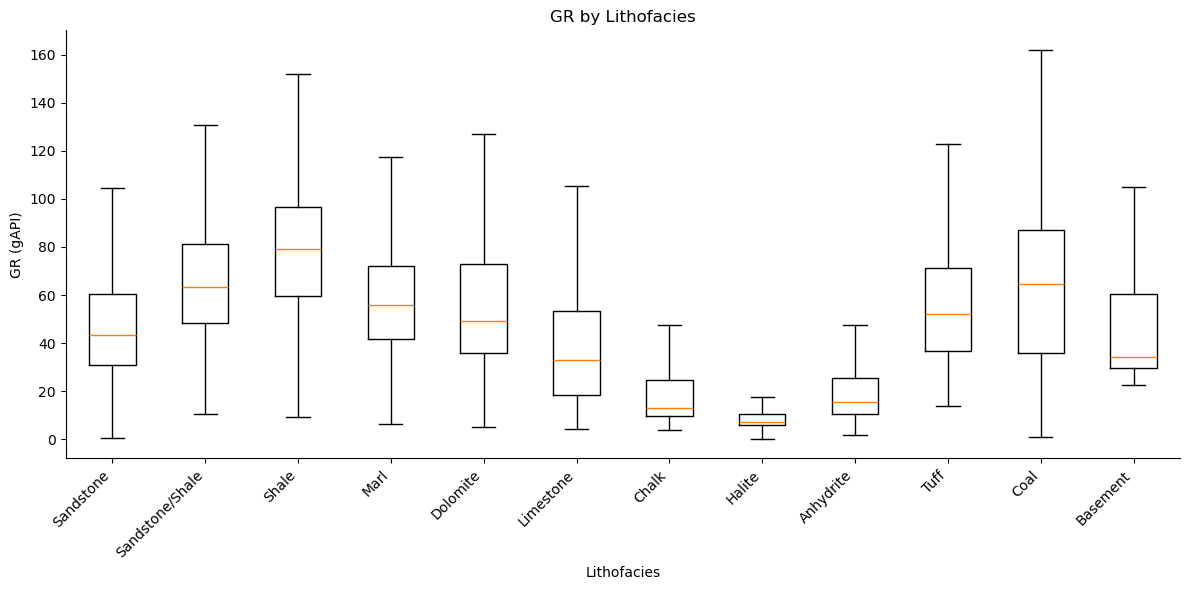

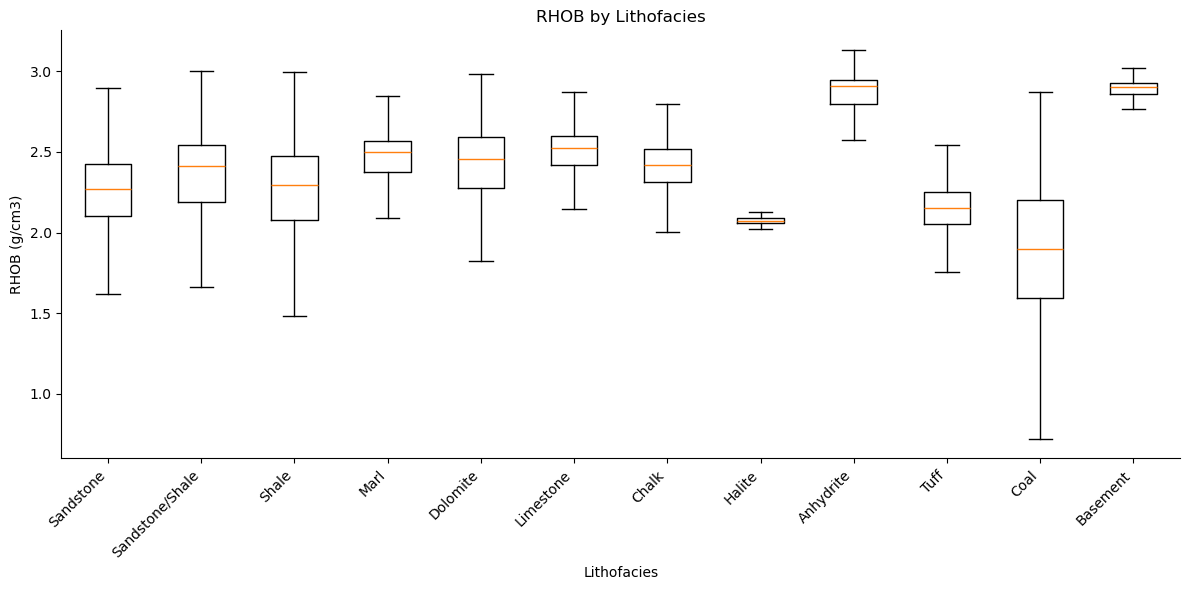

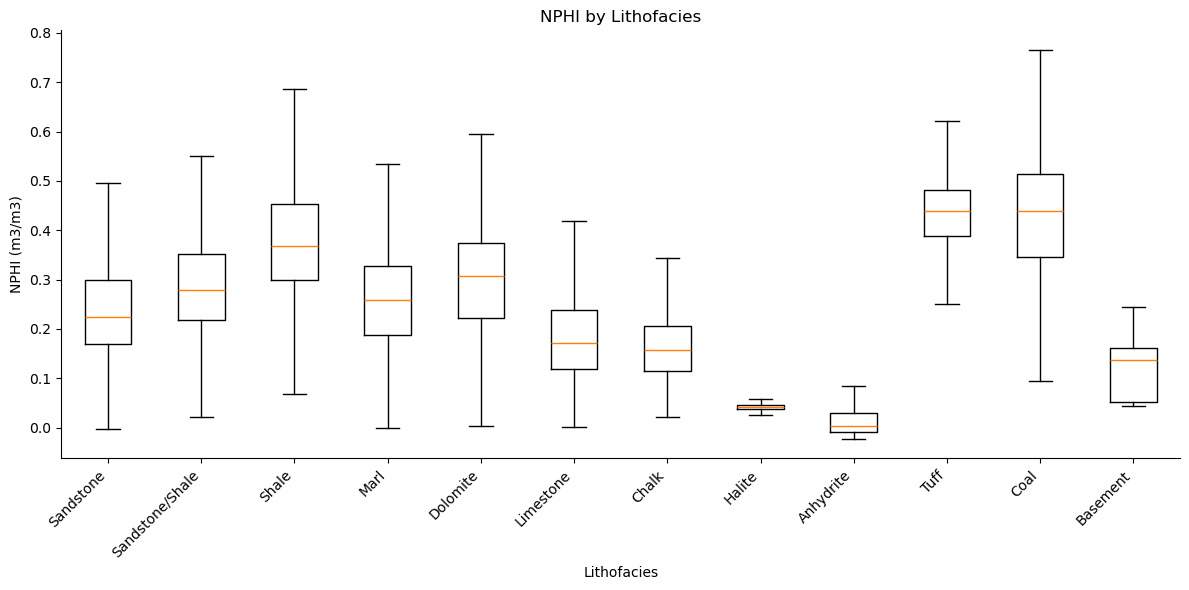

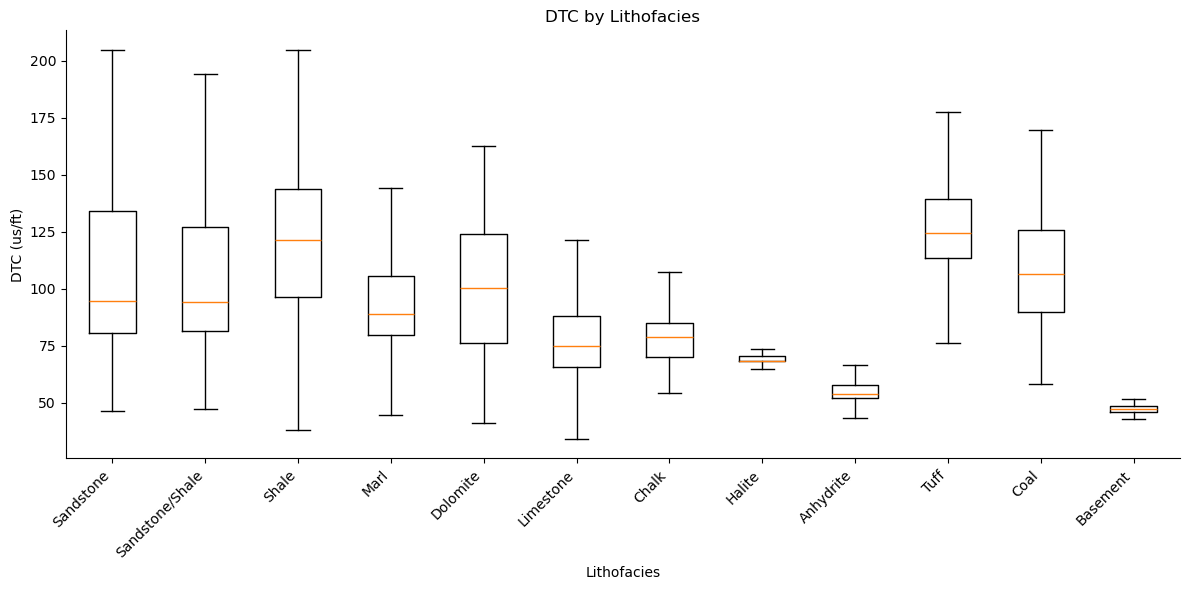

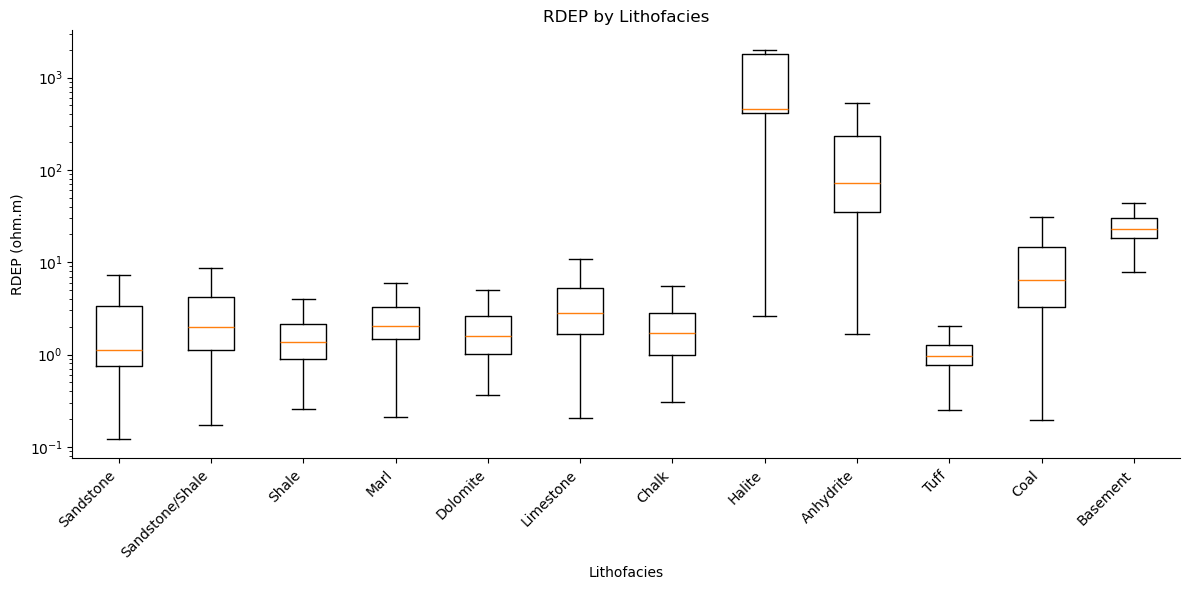

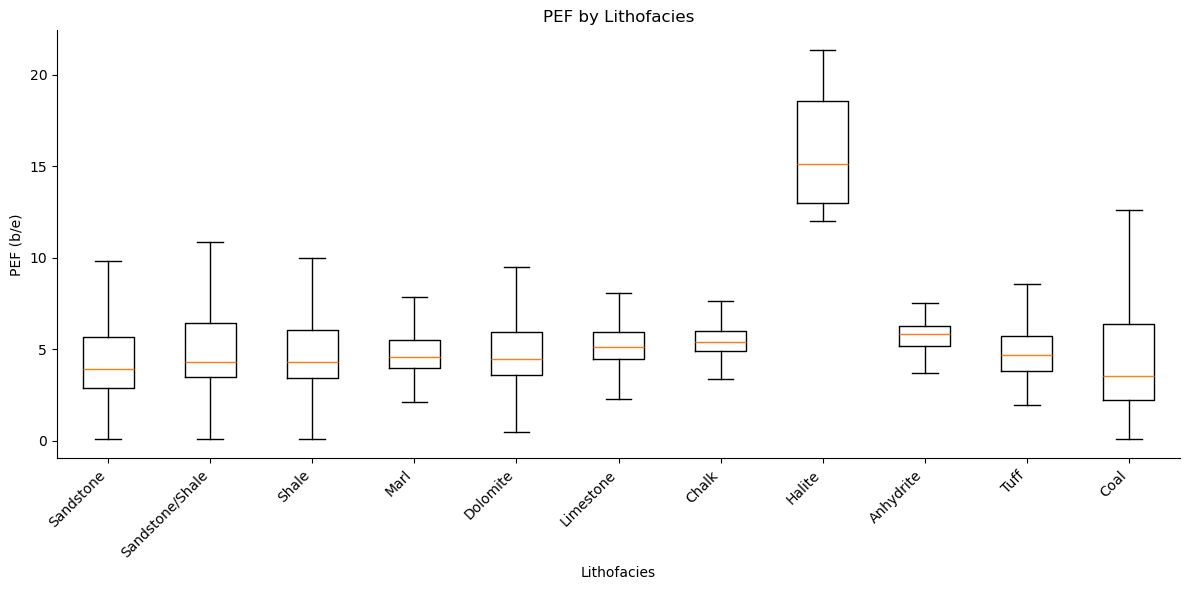

In [34]:
### compare selected logs across lithofacies
def plot_log_by_facies(data, curve):
    plot_data = data[["lithofacies", curve]].dropna().copy()

    if curve == "RDEP":
        plot_data = plot_data.loc[plot_data[curve] > 0]

    available_facies = [
        facies
        for facies in facies_order
        if (plot_data["lithofacies"] == facies).any()
    ]

    groups = [
        plot_data.loc[
            plot_data["lithofacies"] == facies,
            curve,
        ].to_numpy()
        for facies in available_facies
    ]

    fig, ax = plt.subplots(figsize=(12, 6))

    ax.boxplot(
        groups,
        showfliers=False,
    )
    ax.set_xticks(range(1, len(available_facies) + 1))
    ax.set_xticklabels(available_facies)

    if curve == "RDEP":
        ax.set_yscale("log")

    ax.set_ylabel(curve_label(curve))
    ax.set_xlabel("Lithofacies")
    ax.set_title(f"{curve} by Lithofacies")
    ax.tick_params(axis="x", rotation=45)
    plt.setp(ax.get_xticklabels(), ha="right")
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    plt.tight_layout()
    plt.show()


for curve in KEY_LOGS:
    plot_log_by_facies(facies_plot_sample, curve)

## 6. Cross-log correlation

The matrix below is a pooled, sample-level Pearson correlation across the principal logs. `RDEP` is transformed to `log10(RDEP)` because its raw distribution is strongly right-skewed. 

In [35]:
### prepare a bounded sample for correlation calculation
correlation_columns = [
    "GR",
    "RHOB",
    "NPHI",
    "DTC",
    "PEF",
]

correlation_data = samples[correlation_columns + ["RDEP"]].copy()
positive_rdep = correlation_data["RDEP"].where(
    correlation_data["RDEP"] > 0
)
correlation_data["LOG10_RDEP"] = np.log10(positive_rdep)
correlation_data = correlation_data.drop(columns="RDEP")

if len(correlation_data) > 250000:
    correlation_data = correlation_data.sample(
        n=250000,
        random_state=42,
    )

correlation_matrix = correlation_data.corr(
    method="pearson",
    min_periods=100,
)

correlation_matrix

,GR,RHOB,NPHI,DTC,PEF,LOG10_RDEP
GR,1.00,0.13,0.21,0.02,-0.09,-0.01
RHOB,0.13,1.00,-0.62,-0.36,-0.12,0.35
NPHI,0.21,-0.62,1.00,0.80,0.02,-0.51
DTC,0.02,-0.36,0.80,1.00,0.03,-0.52
PEF,-0.09,-0.12,0.02,0.03,1.00,-0.04
LOG10_RDEP,-0.01,0.35,-0.51,-0.52,-0.04,1.00


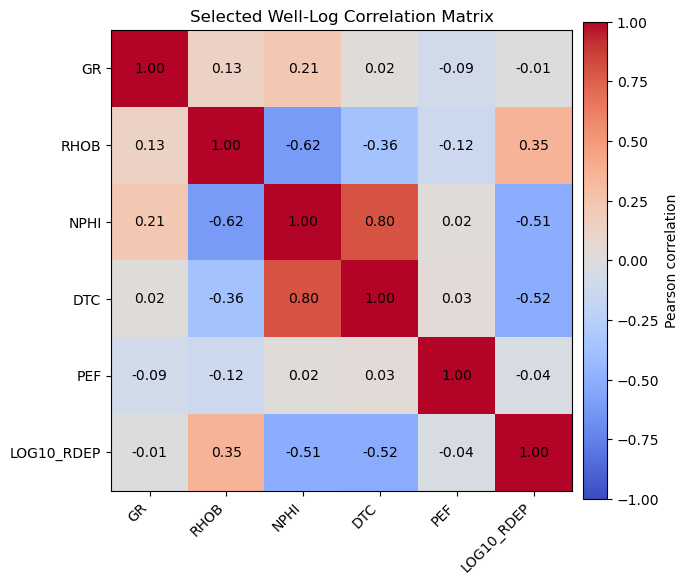

In [36]:
### plot the correlation matrix
fig, ax = plt.subplots(figsize=(7, 6))

image = ax.imshow(
    correlation_matrix.to_numpy(),
    vmin=-1,
    vmax=1,
    cmap="coolwarm",
)

colorbar = fig.colorbar(image, ax=ax, pad=0.02)
colorbar.set_label("Pearson correlation")

labels = correlation_matrix.columns
ax.set_xticks(range(len(labels)))
ax.set_xticklabels(labels, rotation=45, ha="right")
ax.set_yticks(range(len(labels)))
ax.set_yticklabels(labels)

for row in range(len(labels)):
    for column in range(len(labels)):
        value = correlation_matrix.iloc[row, column]
        ax.text(
            column,
            row,
            f"{value:.2f}",
            ha="center",
            va="center",
        )

ax.set_title("Selected Well-Log Correlation Matrix")

plt.tight_layout()
plt.show()

## 7. Select wells for conventional log panels

The panel examples are selected from wells that contain labeled samples. The automatic ranking favors wells with broad coverage across the six principal logs and several represented lithofacies. 

In [37]:
### summarize wells for panel selection
well_log_validity = (
    samples
    .groupby("well", observed=True)[KEY_LOGS]
    .agg(lambda series: series.notna().mean() * 100)
)

well_panel_summary = pd.DataFrame(
    {
        "mean_log_validity": well_log_validity.mean(axis=1),
        "facies_count": (
            labeled_samples
            .groupby("well", observed=True)["lithofacies"]
            .nunique()
        ),
        "labeled_samples": (
            labeled_samples
            .groupby("well", observed=True)
            .size()
        ),
    }
).fillna(0)

well_panel_summary["selection_score"] = (
    well_panel_summary["mean_log_validity"]
    + 3 * well_panel_summary["facies_count"]
)

well_panel_summary = well_panel_summary.sort_values(
    ["selection_score", "labeled_samples"],
    ascending=False,
)

PANEL_WELLS = well_panel_summary.head(3).index.astype(str).tolist()

print("Automatically selected panel wells:")
for well in PANEL_WELLS:
    print(f"  {well}")

well_panel_summary.head(15)

Automatically selected panel wells:
  34/10-16R
  33/9-17
  15/9-14


,mean_log_validity,facies_count,labeled_samples,selection_score
well,,,,
34/10-16R,92.90,8,25095,116.90
33/9-17,91.88,8,17869,115.88
15/9-14,91.26,8,20336,115.26
31/2-8,90.66,8,19026,114.66
25/2-7,90.35,8,25131,114.35
34/10-21,87.76,8,22491,111.76
31/2-9,96.26,5,8753,111.26
15/9-13 Sleipner East Appr,87.09,8,18270,111.09
35/11-6,89.26,7,23674,110.26


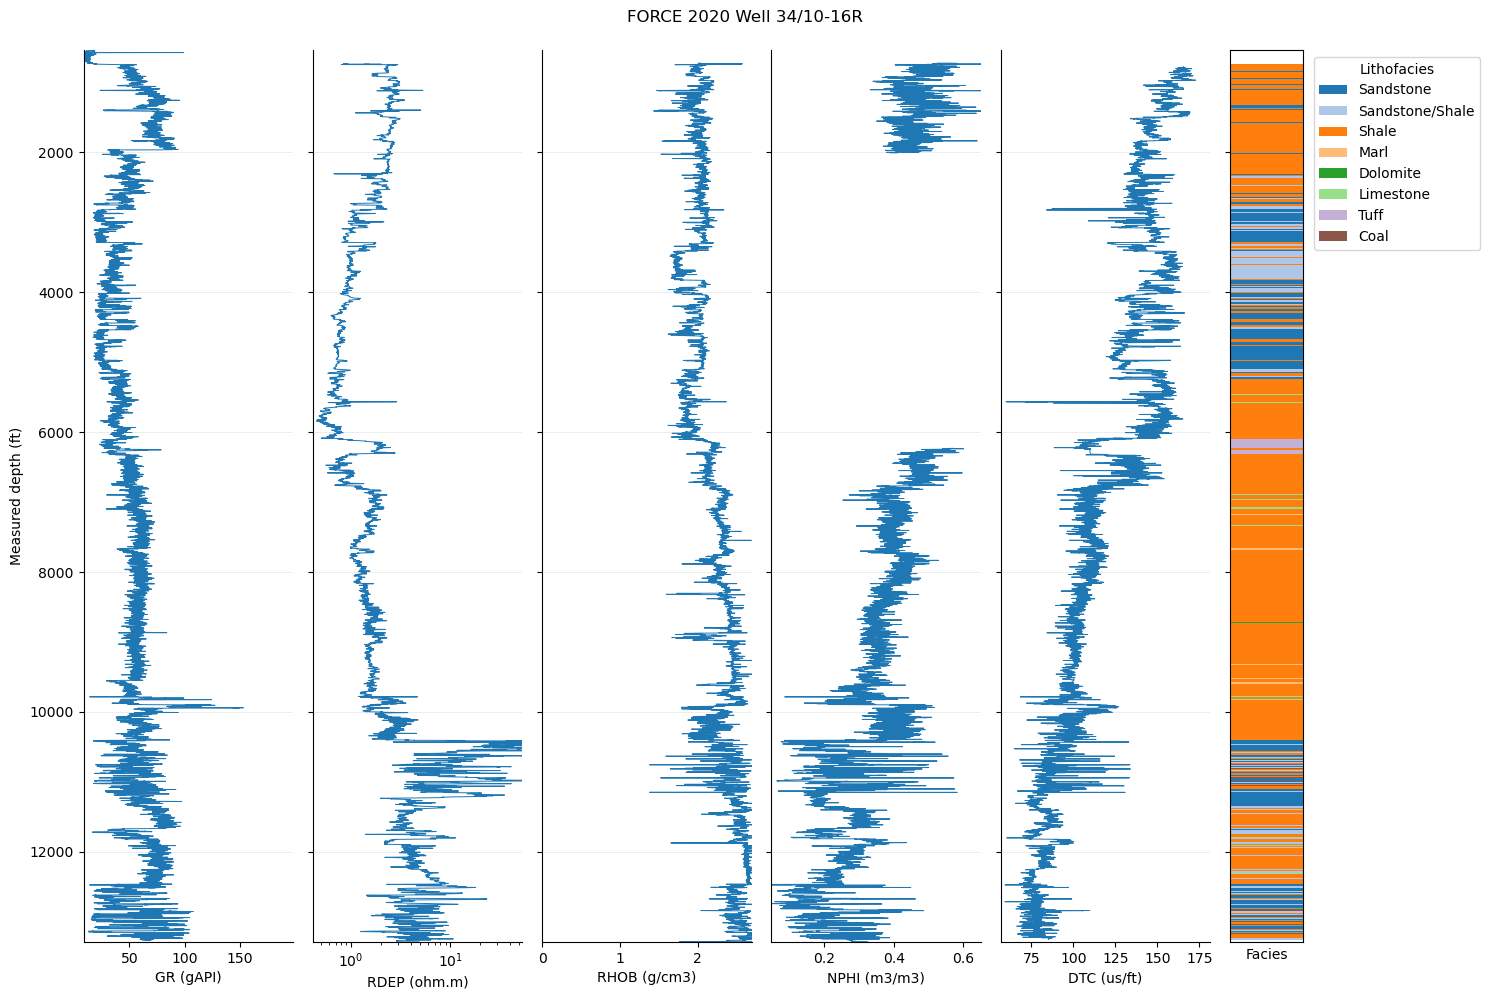

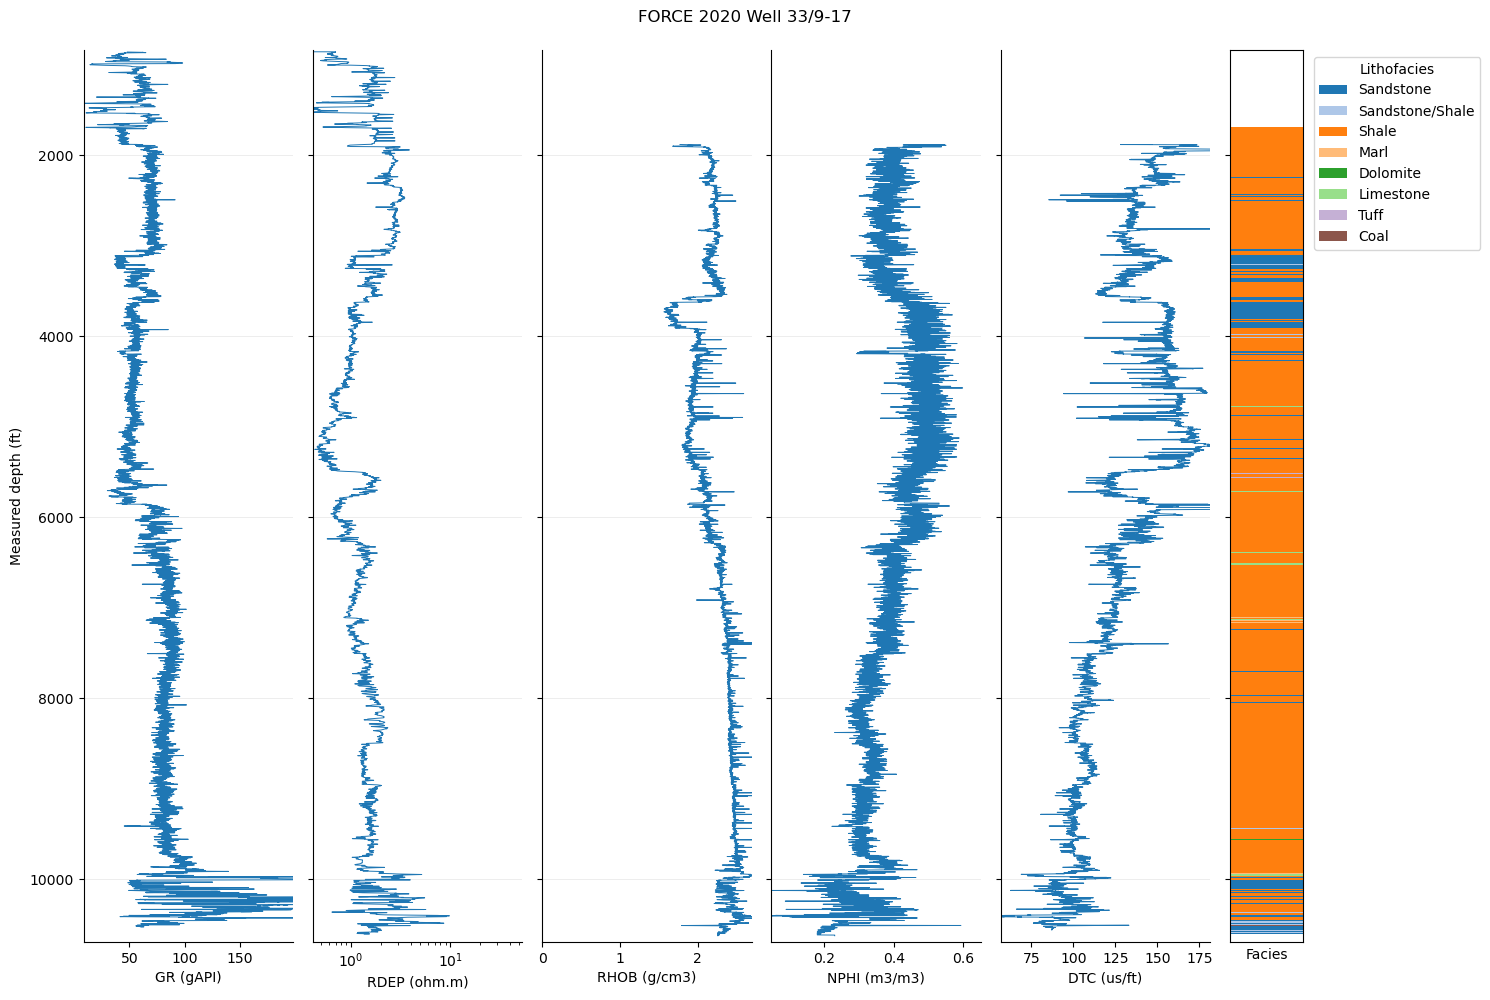

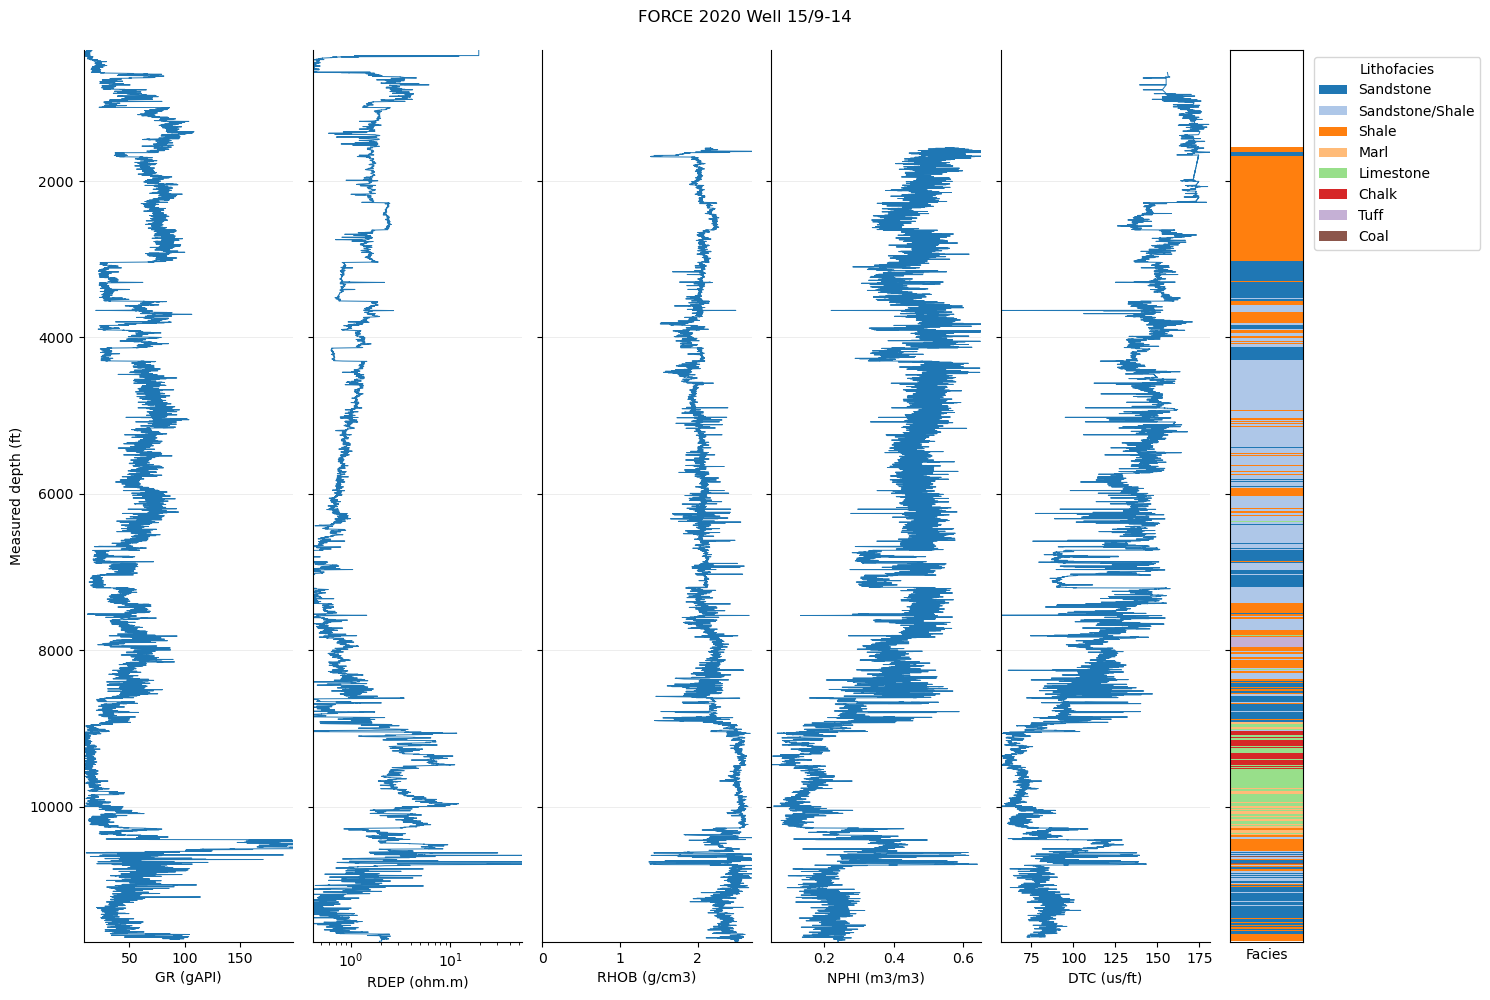

In [38]:
### define a categorical facies colormap for log panels
facies_colors = [FACIES_COLORS[facies] for facies in facies_order]
facies_cmap = mcolors.ListedColormap(facies_colors)
facies_to_index = {facies: index for index, facies in enumerate(facies_order)}


def plot_well_panel(data, well):
    well_data = (
        data.loc[data["well"].astype(str) == str(well)]
        .sort_values("depth_ft")
        .copy()
    )

    if well_data.empty:
        print(f"No data found for {well}")
        return

    panel_curves = ["GR", "RDEP", "RHOB", "NPHI", "DTC"]
    fig, axes = plt.subplots(
        1,
        len(panel_curves) + 1,
        figsize=(15, 10),
        sharey=True,
        gridspec_kw={"width_ratios": [1, 1, 1, 1, 1, 0.35]},
    )

    depth_ft = well_data["depth_ft"].to_numpy()

    for ax, curve in zip(axes[:-1], panel_curves):
        values = pd.to_numeric(
            well_data[curve],
            errors="coerce",
        )

        ax.plot(
            values,
            depth_ft,
            linewidth=0.7,
        )

        lower, upper = plot_limits[curve]
        if np.isfinite(lower) and np.isfinite(upper) and lower < upper:
            ax.set_xlim(lower, upper)

        if curve == "RDEP":
            positive = values.loc[values > 0]
            if not positive.empty:
                ax.set_xscale("log")

        ax.set_xlabel(curve_label(curve))
        ax.grid(axis="y", linewidth=0.4, alpha=0.4)
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)

    axes[0].set_ylabel("Measured depth (ft)")

    facies_values = (
        well_data["lithofacies"]
        .astype(object)
        .map(facies_to_index)
    )
    facies_array = np.ma.masked_invalid(
        pd.to_numeric(facies_values, errors="coerce")
        .to_numpy(dtype=float)
    )

    facies_ax = axes[-1]
    facies_ax.imshow(
        facies_array[:, np.newaxis],
        aspect="auto",
        interpolation="nearest",
        cmap=facies_cmap,
        vmin=-0.5,
        vmax=len(facies_order) - 0.5,
        extent=[0, 1, np.nanmax(depth_ft), np.nanmin(depth_ft)],
    )
    facies_ax.set_xticks([])
    facies_ax.set_xlabel("Facies")

    axes[0].set_ylim(
        np.nanmax(depth_ft),
        np.nanmin(depth_ft),
    )

    present_facies = [
        facies
        for facies in facies_order
        if facies in set(well_data["lithofacies"].dropna().astype(str))
    ]

    legend_handles = [
        Patch(
            facecolor=facies_colors[facies_to_index[facies]],
            label=facies,
        )
        for facies in present_facies
    ]

    if legend_handles:
        facies_ax.legend(
            handles=legend_handles,
            loc="upper left",
            bbox_to_anchor=(1.05, 1),
            title="Lithofacies",
        )

    fig.suptitle(
        f"FORCE 2020 Well {well}",
        y=0.995,
    )

    plt.tight_layout()
    plt.show()


for well in PANEL_WELLS:
    plot_well_panel(samples, well)

## 8. Crossplots

In [39]:
### crossplots test whether lithofacies occupy distinct fields when two log responses are joined together
### separation indicates discriminatory information, while overlap shows where the log pair remains lithologically ambiguous

In [40]:
### define consistent lithofacies colors
### use lithofacies color key
crossplot_color_map = FACIES_COLORS


### prepare paired log data and quantify valid coverage by lithofacies
def prepare_crossplot(data, x_curve, y_curve, max_per_facies=5000,
                      log10_x=False, log10_y=False):
    pair_data = data[["lithofacies", x_curve, y_curve]].copy()

    for curve in (x_curve, y_curve):
        pair_data[curve] = pd.to_numeric(pair_data[curve], errors="coerce")

    x_plot, y_plot = x_curve, y_curve

    ### log-transform only positive values where requested
    if log10_x:
        pair_data = pair_data.loc[pair_data[x_curve] > 0].copy()
        x_plot = f"LOG10_{x_curve}"
        pair_data[x_plot] = np.log10(pair_data[x_curve])

    if log10_y:
        pair_data = pair_data.loc[pair_data[y_curve] > 0].copy()
        y_plot = f"LOG10_{y_curve}"
        pair_data[y_plot] = np.log10(pair_data[y_curve])

    ### require a lithofacies label and both plotted measurements
    pair_data = pair_data.dropna(subset=["lithofacies", x_plot, y_plot])

    ### measure how much of each lithofacies can enter the crossplot
    facies_totals = data.groupby("lithofacies", observed=True).size()
    coverage = (
        pair_data.groupby("lithofacies", observed=True)
        .size()
        .rename("valid_pairs")
        .to_frame()
    )
    coverage["facies_rows"] = facies_totals.reindex(coverage.index)
    coverage["coverage_pct"] = 100 * coverage["valid_pairs"] / coverage["facies_rows"]

    ### cap each facies only for plotting so common classes do not dominate
    plot_data = stratified_plot_sample(
        pair_data, "lithofacies", max_per_group=max_per_facies
    )

    return pair_data, plot_data, coverage, x_plot, y_plot

In [41]:
### plot empirical lithofacies fields for a selected log pair
def plot_lithofacies_crossplot(data, x_curve, y_curve, max_per_facies=3000,
                               log10_x=False, log10_y=False):
    pair_data, plot_data, coverage, x_plot, y_plot = prepare_crossplot(
        data=data, x_curve=x_curve, y_curve=y_curve,
        max_per_facies=max_per_facies, log10_x=log10_x, log10_y=log10_y
    )

    fig, ax = plt.subplots(figsize=(9, 7))

    ### plot each lithofacies as a separate empirical point cloud
    for facies in facies_order:
        facies_data = plot_data.loc[plot_data["lithofacies"] == facies]

        if facies_data.empty:
            continue

        ax.scatter(
            facies_data[x_plot], facies_data[y_plot],
            s=8, alpha=0.5, linewidths=0,
            color=crossplot_color_map[facies], label=facies, rasterized=True
        )

    ### use central limits for display without changing coverage statistics
    x_lower, x_upper = central_plot_range(pair_data[x_plot])
    y_lower, y_upper = central_plot_range(pair_data[y_plot])

    if np.isfinite([x_lower, x_upper]).all():
        ax.set_xlim(x_lower, x_upper)

    if np.isfinite([y_lower, y_upper]).all():
        ax.set_ylim(y_lower, y_upper)

    x_label = f"log10({x_curve})" if log10_x else curve_label(x_curve)
    y_label = f"log10({y_curve})" if log10_y else curve_label(y_curve)

    ax.set_xlabel(x_label)
    ax.set_ylabel(y_label)
    ax.set_title(
        f"{x_curve} vs {y_curve} by Lithofacies\n"
        f"{len(pair_data):,} valid labeled pairs"
    )

    ax.legend(
        title="Lithofacies", bbox_to_anchor=(1.02, 1),
        loc="upper left", frameon=False, markerscale=2
    )

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    plt.tight_layout()
    plt.show()

    return coverage

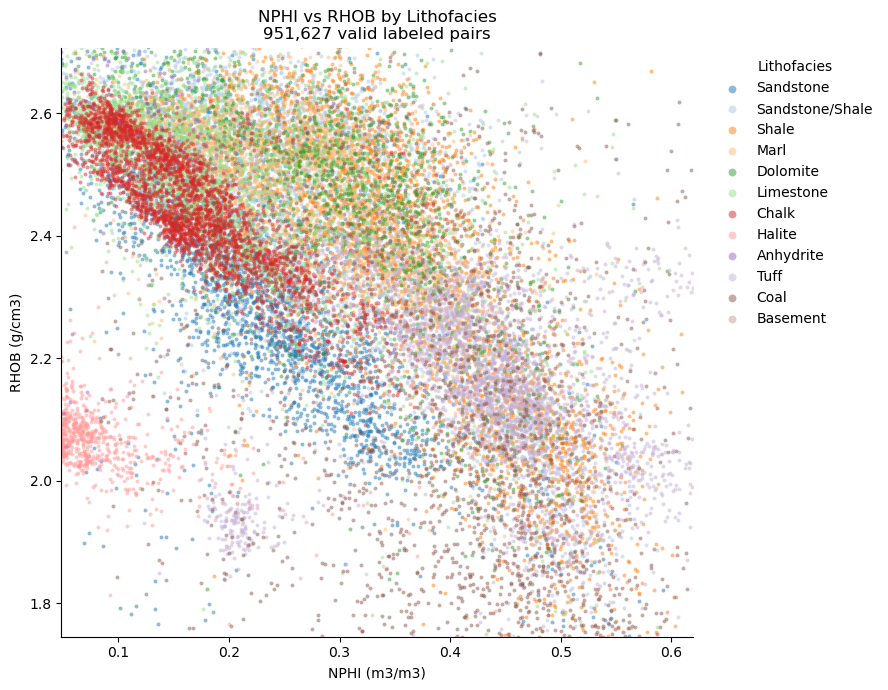

,valid_pairs,facies_rows,coverage_pct
lithofacies,,,
Sandstone,146314,207704,70.44
Sandstone/Shale,116675,180820,64.53
Shale,572859,877043,65.32
Marl,32665,41038,79.60
Dolomite,1534,2391,64.16
Limestone,51570,69498,74.20
Chalk,10294,14043,73.30
Halite,5100,14712,34.67
Anhydrite,1480,1808,81.86


In [42]:
### nphi-rhob compares complementary neutron and bulk-density responses
### the pair tests whether lithofacies occupy distinct hydrogen-response and density fields
nphi_rhob_coverage = plot_lithofacies_crossplot(
    labeled_samples,
    x_curve="NPHI",
    y_curve="RHOB",
)

display(nphi_rhob_coverage)

#### Observations :
Overall inverse trend between bulk density (RHOB) and neutron porosity (NPHI). Some concentrated lobes/fields for chalk and tuff, with high-RHOB/low-NPHI (high density/low porosity) and medium-RHOB/high-NPHI (medium density/high porosity) respectively. Halite concentrates mostly between values of 2-2.1 g/cm^3 and under 10 % porosity. Tuff seems to have a tangible secondary concentration group at about 1.9 g/cm^3 and 20% porosity. Sandstone/shales cover a very broad unlocalized plot area while sandstones appear to follow broadly the inverse path under chalk and tuff while marls seem to lie above the chalk lobe.

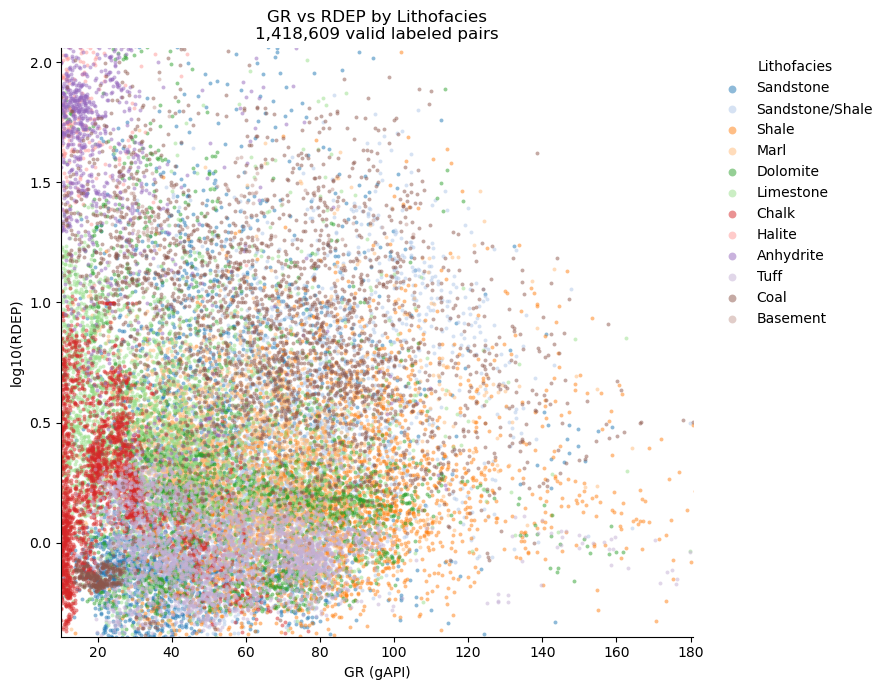

,valid_pairs,facies_rows,coverage_pct
lithofacies,,,
Sandstone,205946,207704,99.15
Sandstone/Shale,179205,180820,99.11
Shale,874140,877043,99.67
Marl,40368,41038,98.37
Dolomite,2385,2391,99.75
Limestone,69478,69498,99.97
Chalk,12900,14043,91.86
Halite,10417,14712,70.81
Anhydrite,1482,1808,81.97


In [43]:
### gr-log10(rdep) compares natural radioactivity with deep electrical resistivity
### resistivity is log-transformed to represent its orders-of-magnitude variation more clearly
gr_rdep_coverage = plot_lithofacies_crossplot(
    labeled_samples,
    x_curve="GR",
    y_curve="RDEP",
    log10_y=True,
)

display(gr_rdep_coverage)

GR reports natural radioactivity useful for lithological identification, while RDEP is sensitive to pore-fluid conductivity, saturation, porosity, and clay content.

##### Observations :


Overall a very large undefined field for sandstones. More localized lobes for tuff (under 0.4
log10 RDEP and under 100 gAPI) and chalk which has a more linear profile with most points
under 1 log10 RDEP and less than 40 gAPI. Other facies are not easily grouped visually.

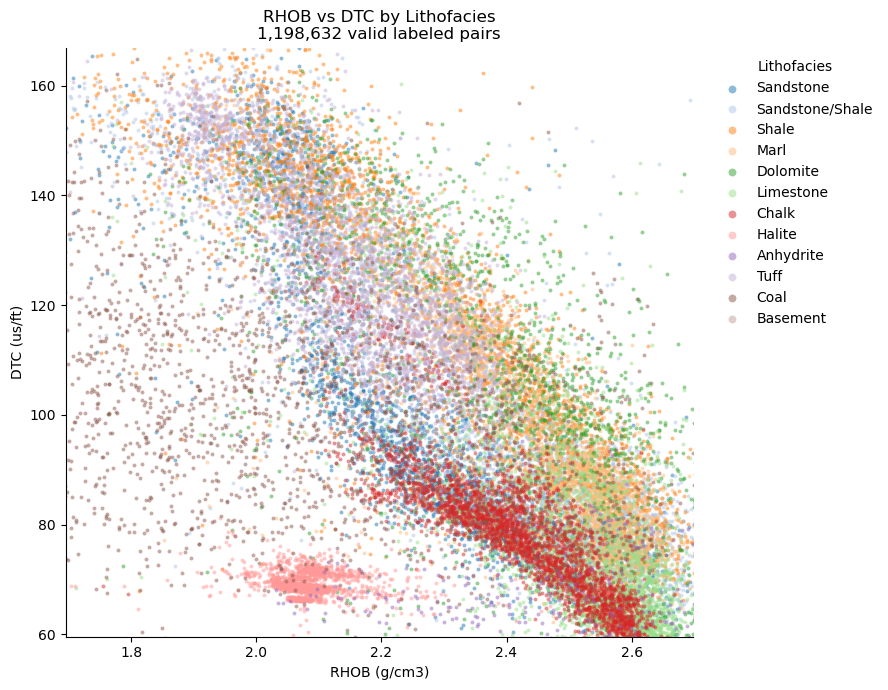

,valid_pairs,facies_rows,coverage_pct
lithofacies,,,
Sandstone,179321,207704,86.33
Sandstone/Shale,150016,180820,82.96
Shale,723077,877043,82.44
Marl,39735,41038,96.82
Dolomite,1966,2391,82.23
Limestone,64927,69498,93.42
Chalk,12020,14043,85.59
Halite,5753,14712,39.10
Anhydrite,1639,1808,90.65


In [44]:
### rhob-dtc compares bulk density with compressional acoustic slowness
### the pair tests whether facies differ in combined density and acoustic response
rhob_dtc_coverage = plot_lithofacies_crossplot(
    labeled_samples,
    x_curve="RHOB",
    y_curve="DTC",
)

display(rhob_dtc_coverage)

##### Observations :
Overall very strong linear inverse trends for some facies including chalk, shale, tuff and marl
while limestone and halite appear as localized clusters/lobes. Sandstones are still mostly
diffuse accross the plot.
- halite roughly between 2 and 2.2 g/cm3 and under 75 microsecond/ft
- chalk roughly between 2.2 and 2.6 g/cm3 and under 90 microseconds/ft
- tuff roughly between 1.9 and 2.4 g/c3 and between 160 and 100 microseconds/ft
- marl roughly between 2.2 and around 2.6 g/cm3 and under 110 microseconds/ft
- limestone roughly between 2.3 and over 2.6 g/cm3 and under 90 microseconds/ft
- shale roughly between 1.7 to over 2.6 g/cm3 and then 165 to 70 microseconds/ft

The strong overall structure indicates a shared rock-property relationship. This might be expected since as density increases, compressional slowness decreases. This is consistent with changes in porosity and compaction. Lithofacies modify this relationship, but most classes do not occupy defined fields.


##### Summary crossplot observation :

All three crossplots show significant overlap between facies. Some of the less common lithologies form clearer clusters, but sandstone, sandstone/shale and shale remain much harder to separate. No two-log combination examined herein can identify lithology on its own, though each add some useful separation.
The broad overlaps indicate that each combination alone would be insufficient to distinguish lithofacies reliably.


## 9. EDA summary tables

In [45]:
### summarize the principal findings numerically
log_summary = pd.DataFrame(
    {
        "valid_samples": samples[KEY_LOGS].notna().sum(),
        "missing_%": samples[KEY_LOGS].isna().mean() * 100,
        "median": samples[KEY_LOGS].median(),
        "p01": samples[KEY_LOGS].quantile(0.01),
        "p99": samples[KEY_LOGS].quantile(0.99),
    }
)

well_facies_summary = pd.DataFrame(
    {
        "labeled_samples": labeled_samples.groupby(
            "well",
            observed=True,
        ).size(),
        "facies_count": labeled_samples.groupby(
            "well",
            observed=True,
        )["lithofacies"].nunique(),
        "dominant_facies": labeled_samples.groupby(
            "well",
            observed=True,
        )["lithofacies"].agg(
            lambda series: series.value_counts().index[0]
        ),
    }
).sort_values(
    "labeled_samples",
    ascending=False,
)

print("Selected-log summary")
display(log_summary)

print("Wells with the largest labeled sample populations")
display(well_facies_summary.head(15))

Selected-log summary


,valid_samples,missing_%,median,p01,p99
GR,2297684,1.71,68.87,8.69,197.78
RHOB,1396517,40.26,2.31,0.00,2.70
NPHI,1033603,55.78,0.33,0.05,0.65
DTC,1793708,23.27,115.79,56.77,181.41
RDEP,2219193,5.07,1.41,0.41,53.59
PEF,924140,60.47,4.36,1.66,39.71


Wells with the largest labeled sample populations


,labeled_samples,facies_count,dominant_facies
well,,,
25/2-7,25131,8,Shale
34/10-16R,25095,8,Shale
29/6-1,24468,6,Shale
29/3-1,24213,7,Shale
25/7-2,23879,7,Shale
35/11-6,23674,7,Shale
34/2-4,23404,7,Sandstone/Shale
34/11-2 S,23310,8,Shale
25/4-5,23005,7,Shale


In [46]:
### add depth samples to sql database

database_path = (
    data_root_dir
    / "force_2020_well_log_analysis"
    / "database"
    / "force2020.duckdb"
)

connection = duckdb.connect(str(database_path))

connection.register("samples_df", samples)

connection.execute(
    """
    CREATE OR REPLACE TABLE log_samples AS
    SELECT * FROM samples_df
    """
)

connection.close()
print(f'Database path: {database_path}')

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Database path: /Users/user/Desktop/General/projects/data/force_2020_well_log_analysis/database/force2020.duckdb
